# WOrking with LANGCHAIN

In [1]:
!pip install langchain langchain-community langchain-google-genai langchain-experimental --quiet 

In [3]:
from langchain.chat_models import init_chat_model
model = init_chat_model("google_genai:gemini-2.5-flash")
output = model.invoke("Write python code, concise, to print Hello world")
output.content

'```python\nprint("Hello World") \n```'

In [5]:
from langchain_core.prompts import ChatPromptTemplate

prompt_temp = ChatPromptTemplate([("system","Write {n} lines of content on the topic provided "),("user","{topic}")])
prompt_temp

ChatPromptTemplate(input_variables=['n', 'topic'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['n'], input_types={}, partial_variables={}, template='Write {n} lines of content on the topic provided '), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['topic'], input_types={}, partial_variables={}, template='{topic}'), additional_kwargs={})])

In [6]:
prompt_temp.invoke({"n":2,"topic":"Agentic AI"})

ChatPromptValue(messages=[SystemMessage(content='Write 2 lines of content on the topic provided ', additional_kwargs={}, response_metadata={}), HumanMessage(content='Agentic AI', additional_kwargs={}, response_metadata={})])

In [7]:
model.invoke(prompt_temp.invoke({"n":2,"topic":"Agentic AI"}))

AIMessage(content='Agentic AI autonomously takes action to achieve defined goals.\nIt plans, executes, and adapts, orchestrating tools to solve complex problems.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dae58-e6a7-7da0-b90a-37b65cd240da-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 533, 'total_tokens': 548, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 505}})

## WOrking with LANGGRAPH

1. Nodes
2. Edges
3. State Data Model
4. Graph

### Use Case: Sales Analytics Workflow Agent
Agent can fed with Sales data, with columns dates, sales in USD
It can perform a specific set of analytics and provide the report on it in the Markdown format. 
The output report must include:


1. Sales Visualization in line plot
2. Key Trends and seasonalities observed
3. Forecast for next 30 days
4. VIsualization of forecasted data
5. Final Expert Summary and Recommendations


Input: CSV file with sales data


In [16]:
from typing import TypedDict
import pandas as pd

from langchain.chat_models import init_chat_model
model = init_chat_model("google_genai:gemini-2.5-flash")

class stateDM(TypedDict):
    input_file:str
    data_df:pd.DataFrame
    current_viz_path:str
    key_insights:str
    #forecast:str
    #forecast_viz:str
    #final_result:str
    

In [17]:
# Node 1: Data Loading
def data_load(state:stateDM)->stateDM:
    df = pd.read_csv(state['input_file'])
    return {"data_df":df}

In [33]:
def analysis1(state:stateDM)->stateDM:
    """ two parts: visualization export, key trends and seasonalities"""
    code_success=False
    vizfile = "currentViz.png"
    df = state['data_df']
    if not code_success:
        prompt = f"""given the sales data dataframe {df} analyze the same and write python code generate a powerful visualization 
        of current sales, keep grid, background white, trend lines, line plot, only return python code to execute nothing else
        Save the visualization with the file name {vizfile}. Make sure the code must be factually correct"""
        code = model.invoke(prompt).content
        if '```python' in code:
            code = code[9:-3].strip()

        exec(code)
        output = vizfile
    else:
        output = "No File Could be Generated"
    
    return {'current_viz_path':output}



In [ ]:
def analysis2(state:stateDM)->stateDM:
    """ two parts: visualization export, key trends and seasonalities"""
    code_success=False
    
    df = state['data_df']
    if not code_success:
        prompt = f"""given the sales data dataframe {df} analyze the same and write python code to analyze key trends and seasonalities 
        for interpretation. You can keep the code simple and straightforward, no need for regression or forecast for now. 
        make sure the python code execution returns outputs in text. 
        only return python code to execute nothing else. Make sure the code must be factually correct """
        code2 = model.invoke(prompt).content
        if '```python' in code2:
            code2 = code2[9:-3].strip()

        results = exec(code2)
    else:
        results = "No insights Could be Generated"
    
    return {'key_insights':results}



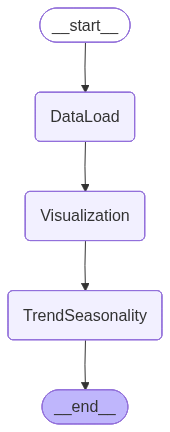

In [44]:
from langgraph.graph import StateGraph, START, END
builder = StateGraph(stateDM)
builder.add_node("DataLoad",data_load)
builder.add_node("Visualization",analysis1)
builder.add_node("TrendSeasonality",analysis2)
builder.add_edge(START,"DataLoad")
builder.add_edge("DataLoad","Visualization")
builder.add_edge("Visualization","TrendSeasonality")
builder.add_edge("TrendSeasonality",END)

graph = builder.compile()
graph

In [45]:
!pip install seaborn statsmodels --quiet

--- Sales Data Analysis Report ---

Data Period: From 2025-06-01 to 2025-12-27 (210 days)

--- 1. Overall Sales Trend ---
Total Sales over the period: $5,786,733.64
Average Daily Sales: $27,555.87
Minimum Daily Sales: $19,555.42
Maximum Daily Sales: $46,160.38
Sales at the start (2025-06-01): $26,993.43
Sales at the end (2025-12-27): $46,160.38
Observation: There is an apparent upward trend in sales over the period, with sales increasing from $26,993.43 to $46,160.38.

--- 2. Monthly Seasonality (Average Daily Sales by Month) ---
- December: $34,399.20
- November: $30,409.60
- October: $26,621.16
- August: $26,216.02
- July: $25,694.68
- September: $25,573.80
- June: $24,798.86

Observation: Sales exhibit monthly seasonality. The months with the highest average daily sales are often at the end of the year (e.g., December, November), while earlier months (e.g., June, July) tend to have lower sales. This suggests a potential year-end surge.

--- 3. Weekly Seasonality (Average Daily Sales

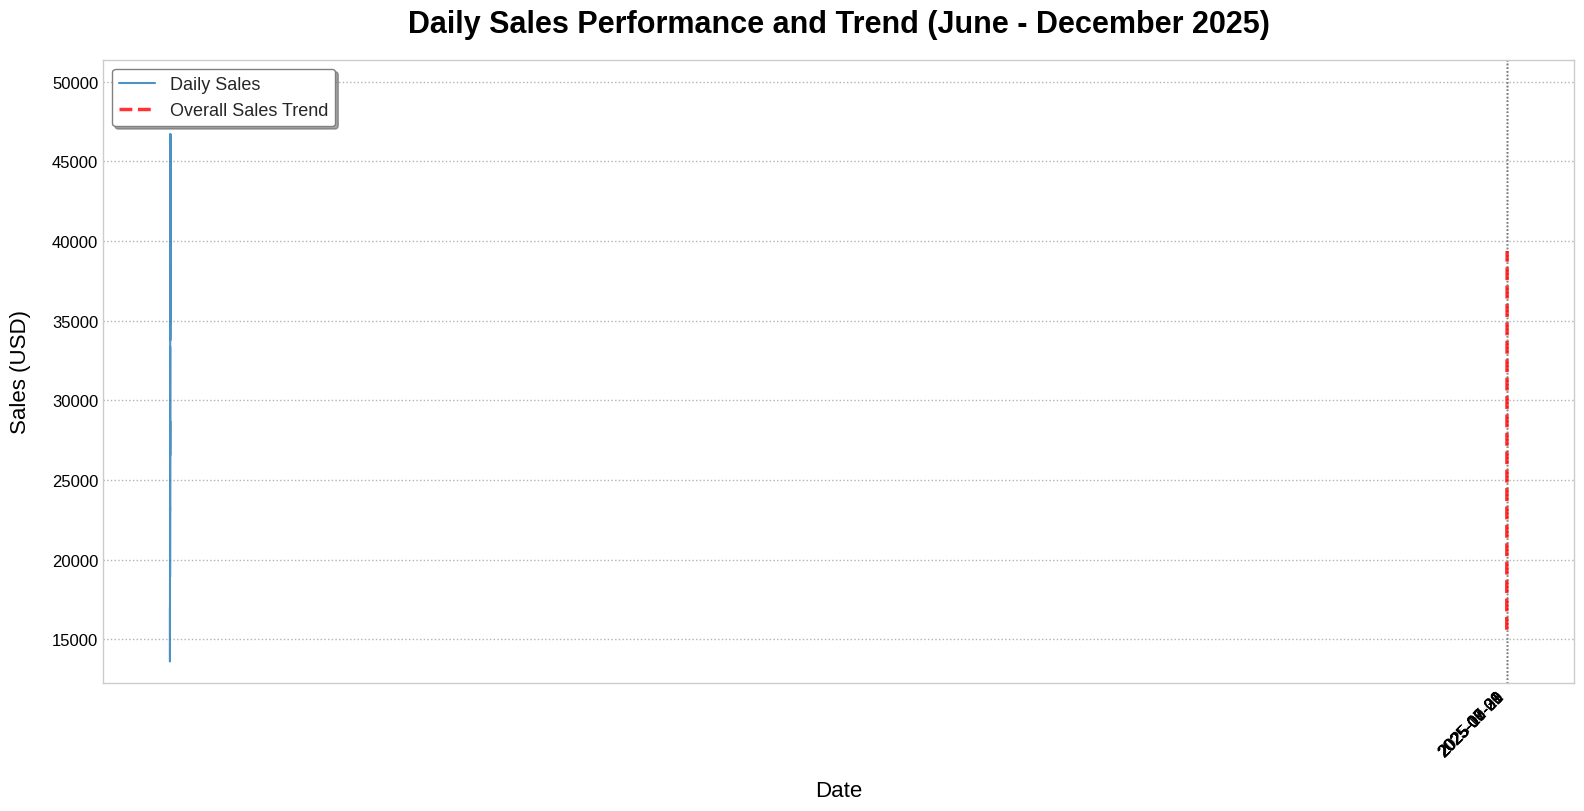

In [46]:
result = graph.invoke({"input_file":"datasets/sales_data_210_days_jun_2025.csv"})

In [47]:
result

{'input_file': 'datasets/sales_data_210_days_jun_2025.csv',
 'data_df':            Date  sales_USD
 0    2025-06-01   16057.55
 1    2025-06-02   18372.74
 2    2025-06-03   17914.86
 3    2025-06-04   17772.58
 4    2025-06-05   17598.78
 ..          ...        ...
 205  2025-12-23   28225.41
 206  2025-12-24   27489.40
 207  2025-12-25   31371.30
 208  2025-12-26   29451.37
 209  2025-12-27   39602.92
 
 [210 rows x 2 columns],
 'current_viz_path': 'currentViz.png',
 'key_insights': None}